In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import RandomUnderSampler

In [2]:
df = pd.read_csv("Admission_Prediction.csv")
print(df.head())

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  \
0           1        337          118                  4  4.5  4.5  9.65   
1           2        324          107                  4  4.0  4.5  8.87   
2           3        316          104                  3  3.0  3.5  8.00   
3           4        322          110                  3  3.5  2.5  8.67   
4           5        314          103                  2  2.0  3.0  8.21   

   Research  Chance of Admit  Year  \
0         1             0.92  2022   
1         1             0.76  2022   
2         1             0.72  2022   
3         1             0.80  2022   
4         0             0.65  2022   

                              University_Name region  
0    Indian Institute of Technology Kharagpur   East  
1  National Institute of Technology Karnataka  South  
2                          Gujarat University   West  
3                        Jamia Millia Islamia  North  
4                        Jamia Millia I

In [3]:
# create the admision class addmision approved or not for chech balaced data 
df["Outcome"] = (df["Chance of Admit"] >= 0.75).astype(int)
print(df["Outcome"].value_counts())

Outcome
0    565
1    435
Name: count, dtype: int64


In [4]:
# select input feature the 
x = df[
    [
        "GRE Score",
        "TOEFL Score",
        "University Rating",
        "SOP",
        "LOR",
        "CGPA",
        "Research",
        "Year"
    ]
]

y = df["Outcome"]

In [5]:
print("before sampling:")
print(y.value_counts())

before sampling:
Outcome
0    565
1    435
Name: count, dtype: int64


In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#stratify=y it keep same class pruportion in data trai and test 

In [7]:
# apply smot method 
smote = SMOTE(random_state=42)

x_smote, y_smote = smote.fit_resample(
    x_train,
    y_train
)

print("after SMOTE:")
print(y_smote.value_counts())
#SMOTE creates new synthetic minority samples.

after SMOTE:
Outcome
0    452
1    452
Name: count, dtype: int64


In [8]:
# apply ADASYN method
adasyn = ADASYN(random_state=42)
x_adasyn, y_adasyn = adasyn.fit_resample(
    x_train,
    y_train
)

print("after ADASYN:")
print(y_adasyn.value_counts())
#ADASYN generates more samples around minority examples that are harder to classify.

after ADASYN:
Outcome
0    452
1    412
Name: count, dtype: int64


In [9]:
# apply under sampling
#under-sampling reduces the number of samples from the majority class.
under = RandomUnderSampler(random_state=42)
x_under, y_under = under.fit_resample(
    x_train,
    y_train
)

print("After under-sampling:")
print(y_under.value_counts())

After under-sampling:
Outcome
0    348
1    348
Name: count, dtype: int64


In [10]:
print("Original:")
print(y_train.value_counts())

print("\nSMOTE:")
print(y_smote.value_counts())

print("\nADASYN:")
print(y_adasyn.value_counts())

print("\nUnder-Sampling:")
print(y_under.value_counts())

Original:
Outcome
0    452
1    348
Name: count, dtype: int64

SMOTE:
Outcome
0    452
1    452
Name: count, dtype: int64

ADASYN:
Outcome
0    452
1    412
Name: count, dtype: int64

Under-Sampling:
Outcome
0    348
1    348
Name: count, dtype: int64


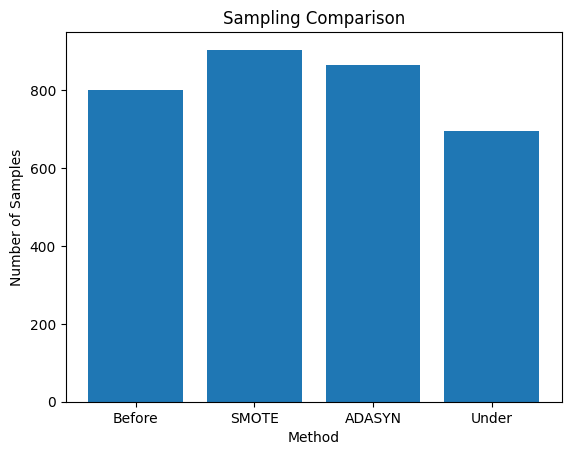

In [11]:
import matplotlib.pyplot as plt

plt.bar(
    ["Before", "SMOTE", "ADASYN", "Under"],
    [
        len(y_train),
        len(y_smote),
        len(y_adasyn),
        len(y_under)
    ]
)

plt.title("Sampling Comparison")
plt.xlabel("Method")
plt.ylabel("Number of Samples")

plt.show()

In [ ]:
#SMOTE performed best because it achieved perfect class balance without removing the original data.